## Support Vector Machine

## Importing Modules

In [ ]:
import pandas as pd
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report
import seaborn as sn

## Load the Dataset

In [ ]:
!curl -L -o /content/diabetes-data-set.zip https://www.kaggle.com/api/v1/datasets/download/mathchi/diabetes-data-set && unzip -o /content/diabetes-data-set.zip && rm /content/diabetes-data-set.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  9128  100  9128    0     0  14666      0 --:--:-- --:--:-- --:--:-- 14666
Archive:  /content/diabetes-data-set.zip
  inflating: diabetes.csv            


## Reading the Dataset

In [ ]:
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
data = pd.read_csv("/content/diabetes.csv", header=None, names=col_names)
data = data.drop(0)
print(data.shape)
data.head()

(768, 9)


,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0
5,0,137,40,35,168,43.1,2.288,33,1


## Check for any null values

In [ ]:
data.isnull().sum()

,0
pregnant,0
glucose,0
bp,0
skin,0
insulin,0
bmi,0
pedigree,0
age,0
label,0


## Assigning dependent and independent variables

In [ ]:
feature_cols = ['pregnant','insulin','bmi','age','glucose','bp','pedigree']
x = data[feature_cols]
y = data.label

## Splitting data into training and testing dataset

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=5)
display(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(614, 7)

(614,)

(154, 7)

(154,)

## Preprocessing data with Standard Scaler

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

## Fitting The Model using 'rbf' kernel

In [ ]:
model = SVC(kernel='rbf',random_state=0)
model.fit(x_train, y_train)
svc_prediction=model.predict(x_test)
print("SVC Prediction", svc_prediction)

SVC Prediction ['0' '0' '0' '0' '0' '0' '0' '1' '1' '0' '0' '0' '1' '0' '0' '0' '0' '1'
 '0' '0' '0' '1' '0' '1' '0' '0' '0' '0' '0' '1' '0' '0' '0' '0' '1' '0'
 '0' '0' '0' '0' '0' '0' '0' '1' '0' '1' '1' '0' '0' '0' '1' '0' '1' '0'
 '0' '0' '0' '0' '1' '0' '1' '0' '1' '0' '0' '0' '0' '1' '1' '0' '1' '0'
 '0' '1' '0' '0' '0' '1' '1' '0' '1' '1' '0' '1' '0' '0' '0' '0' '0' '0'
 '1' '0' '0' '0' '0' '1' '1' '0' '0' '0' '0' '0' '1' '1' '0' '1' '0' '0'
 '1' '0' '0' '1' '0' '0' '0' '0' '0' '1' '0' '0' '1' '1' '0' '0' '0' '0'
 '0' '0' '0' '0' '1' '0' '1' '0' '0' '0' '1' '0' '1' '0' '0' '1' '0' '1'
 '0' '0' '0' '0' '0' '0' '1' '1' '0' '1']


## Evaluation Metrics for 'rbf' kernel

In [ ]:
conf_mat = metrics.confusion_matrix(y_test, svc_prediction)
print("SVC [Kernel - RBF]")
print("Confusion Matrix", conf_mat)
Accuracy_score = metrics.accuracy_score(y_test, svc_prediction)
print("Accuracy", Accuracy_score)
print("Accuracy in Percentage", int(Accuracy_score*100),'%')
print(classification_report(y_test, svc_prediction))


SVC [Kernel - RBF]
Confusion Matrix [[88 12]
 [21 33]]
Accuracy 0.7857142857142857
Accuracy in Percentage 78 %
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       100
           1       0.73      0.61      0.67        54

    accuracy                           0.79       154
   macro avg       0.77      0.75      0.75       154
weighted avg       0.78      0.79      0.78       154



## Confusion Matrix for rbf

[Text(0.5, 1.0, 'SVC [RBF]')]

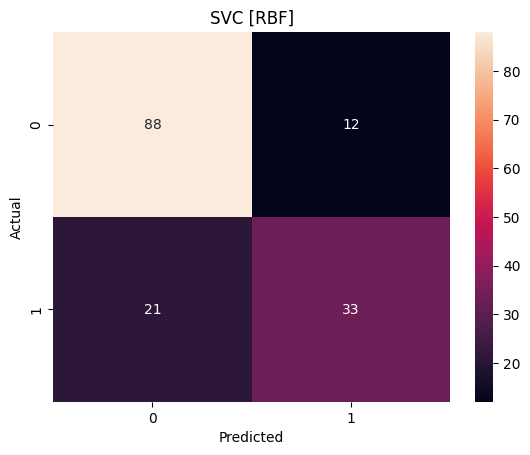

In [ ]:
conf_mat = pd.crosstab(y_test, svc_prediction, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(conf_mat, annot=True).set(title = 'SVC [RBF]')

## Fitting The Model using 'Linear' kernel

In [ ]:
model = SVC(kernel='linear',random_state=0)
model.fit(x_train, y_train)
svc_prediction=model.predict(x_test)
print("SVC Prediction", svc_prediction)

SVC Prediction ['0' '0' '0' '0' '0' '0' '0' '1' '1' '0' '0' '0' '1' '0' '0' '0' '0' '1'
 '0' '0' '0' '1' '0' '1' '0' '0' '0' '0' '0' '1' '0' '0' '0' '0' '1' '0'
 '0' '0' '0' '0' '0' '0' '0' '1' '0' '1' '1' '0' '0' '0' '1' '0' '1' '0'
 '0' '0' '0' '0' '1' '0' '1' '1' '1' '0' '0' '0' '0' '0' '1' '0' '1' '0'
 '0' '1' '1' '0' '0' '1' '1' '0' '0' '1' '1' '1' '0' '0' '0' '0' '0' '0'
 '1' '0' '0' '0' '0' '1' '1' '0' '0' '0' '0' '0' '1' '1' '0' '1' '0' '0'
 '1' '0' '0' '1' '0' '0' '0' '0' '0' '1' '0' '0' '1' '1' '0' '0' '1' '0'
 '0' '0' '0' '0' '0' '0' '1' '0' '0' '0' '1' '0' '1' '0' '0' '1' '0' '1'
 '0' '0' '0' '0' '0' '0' '1' '1' '0' '1']


## Evaluation Metrics for 'Linear' kernel

In [ ]:
conf_mat = metrics.confusion_matrix(y_test, svc_prediction)
print("SVC [Kernel - Linear]")
print("Confusion Matrix", conf_mat)
Accuracy_score = metrics.accuracy_score(y_test, svc_prediction)
print("Accuracy", Accuracy_score)
print("Accuracy in Percentage", int(Accuracy_score*100),'%')
print(classification_report(y_test, svc_prediction))


SVC [Kernel - Linear]
Confusion Matrix [[88 12]
 [20 34]]
Accuracy 0.7922077922077922
Accuracy in Percentage 79 %
              precision    recall  f1-score   support

           0       0.81      0.88      0.85       100
           1       0.74      0.63      0.68        54

    accuracy                           0.79       154
   macro avg       0.78      0.75      0.76       154
weighted avg       0.79      0.79      0.79       154



## Confusion Matrix for Linear

[Text(0.5, 1.0, 'SVC [Linear]')]

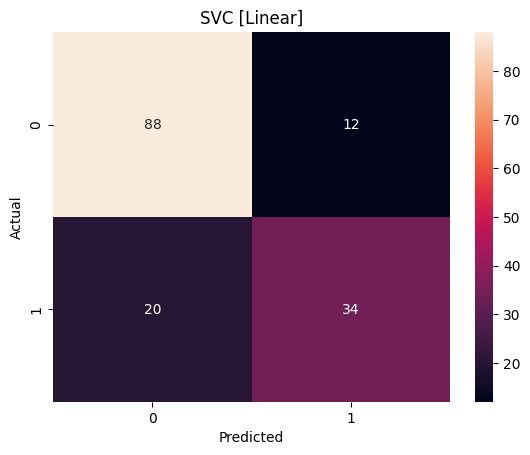

In [ ]:
conf_mat = pd.crosstab(y_test, svc_prediction, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(conf_mat, annot=True).set(title = 'SVC [Linear]')